In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

print("Imports completed successfully!")

Imports completed successfully!


In [6]:
# 1. FILE PATHS (Update paths if files are in a subdirectory)
BANK_CDR_PATH = r"C:\Users\Arpit Mishra\Desktop\AI-Bank-Transaction-and-Telecom-Analyzer\data\new_reduced\bank_cdr_ground_truth_reduced.csv"
CDR_IPDR_PATH = r"C:\Users\Arpit Mishra\Desktop\AI-Bank-Transaction-and-Telecom-Analyzer\data\new_reduced\cdr_ipdr_ground_truth_reduced.csv"


# 2. LOAD DATASETS
bank_cdr_df = pd.read_csv(BANK_CDR_PATH)
cdr_ipdr_df = pd.read_csv(CDR_IPDR_PATH)

# Strip hidden whitespace from column names
bank_cdr_df.columns = bank_cdr_df.columns.str.strip()
cdr_ipdr_df.columns = cdr_ipdr_df.columns.str.strip()

print(f"Loaded bank_cdr_df shape: {bank_cdr_df.shape}")
print(f"Loaded cdr_ipdr_df shape: {cdr_ipdr_df.shape}")

# 3. MERGE ON CDR_ID
fused_df = pd.merge(
    bank_cdr_df,
    cdr_ipdr_df,
    on="CDR_ID",
    how="outer",
    suffixes=("_bank_cdr", "_cdr_ipdr")
)

print(f"Merged fused_df shape: {fused_df.shape}")

# 4. FEATURE ENGINEERING
fused_df["Time_Difference_Seconds_bank_cdr"] = fused_df["Time_Difference_Seconds_bank_cdr"].fillna(9999.0)
fused_df["Time_Difference_Seconds_cdr_ipdr"] = fused_df["Time_Difference_Seconds_cdr_ipdr"].fillna(9999.0)
fused_df["Is_Correlated_bank_cdr"] = fused_df["Is_Correlated_bank_cdr"].fillna(0.0)
fused_df["Is_Correlated_cdr_ipdr"] = fused_df["Is_Correlated_cdr_ipdr"].fillna(0.0)

# Calculate absolute time deltas (for ML anomaly feature space)
fused_df["abs_time_diff_bank_cdr"] = fused_df["Time_Difference_Seconds_bank_cdr"].abs()
fused_df["abs_time_diff_cdr_ipdr"] = fused_df["Time_Difference_Seconds_cdr_ipdr"].abs()

feature_cols = [
    "Time_Difference_Seconds_bank_cdr",
    "Time_Difference_Seconds_cdr_ipdr",
    "Is_Correlated_bank_cdr",
    "Is_Correlated_cdr_ipdr",
    "abs_time_diff_bank_cdr",
    "abs_time_diff_cdr_ipdr"
]

print(f"\nFinal feature matrix constructed with features: {feature_cols}")
X = fused_df[feature_cols].values

Loaded bank_cdr_df shape: (10017, 5)
Loaded cdr_ipdr_df shape: (9412, 5)
Merged fused_df shape: (12900, 9)

Final feature matrix constructed with features: ['Time_Difference_Seconds_bank_cdr', 'Time_Difference_Seconds_cdr_ipdr', 'Is_Correlated_bank_cdr', 'Is_Correlated_cdr_ipdr', 'abs_time_diff_bank_cdr', 'abs_time_diff_cdr_ipdr']


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Export Scaler artifact for backend
joblib.dump(scaler, "scaler.pkl")
print("Saved 'scaler.pkl' successfully!")

Saved 'scaler.pkl' successfully!


In [8]:
iso_forest = IsolationForest(
    contamination=0.01, 
    random_state=42, 
    n_estimators=200
)
iso_forest.fit(X_scaled)

# Export Isolation Forest artifact for backend
joblib.dump(iso_forest, "iso_forest.pkl")
print("Saved 'iso_forest.pkl' successfully!")

# Compute Normalized Anomaly Score (Higher = More Anomalous)
raw_iso_scores = -iso_forest.decision_function(X_scaled)
min_iso, max_iso = raw_iso_scores.min(), raw_iso_scores.max()
fused_df["iso_score"] = (raw_iso_scores - min_iso) / (max_iso - min_iso + 1e-6)

Saved 'iso_forest.pkl' successfully!


In [9]:
class FraudAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(FraudAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)  # Bottleneck layer
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

input_dim = len(feature_cols)
autoencoder = FraudAutoencoder(input_dim)

tensor_x = torch.FloatTensor(X_scaled)
dataset = TensorDataset(tensor_x, tensor_x)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.01)

# Training loop
epochs = 20
autoencoder.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x, _ in dataloader:
        optimizer.zero_grad()
        reconstructed = autoencoder(batch_x)
        loss = criterion(reconstructed, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

# Export PyTorch weights artifact for backend
torch.save(autoencoder.state_dict(), "autoencoder.pth")
print("Saved 'autoencoder.pth' successfully!")

# Compute Reconstruction Error (MSE Loss)
autoencoder.eval()
with torch.no_grad():
    reconstructions = autoencoder(tensor_x)
    mse_loss = torch.mean((tensor_x - reconstructions) ** 2, dim=1).numpy()

# Min-Max Normalization to [0, 1]
min_ae, max_ae = mse_loss.min(), mse_loss.max()
fused_df["ae_score"] = (mse_loss - min_ae) / (max_ae - min_ae + 1e-6)

Saved 'autoencoder.pth' successfully!


In [10]:
# Composite Category 3 ML Score (Max Pooling between ISO & AE)
fused_df["category_3_score"] = np.maximum(fused_df["iso_score"], fused_df["ae_score"])

print("--- Category 3 Training & Artifact Export Complete ---")
print("Generated backend artifacts: scaler.pkl, iso_forest.pkl, autoencoder.pth\n")

print("Top 10 Detected Anomalous Transactions (Category 3 Output):")
display(
    fused_df.sort_values(by="category_3_score", ascending=False)[
        ["Transaction_ID", "CDR_ID", "IPDR_ID", "iso_score", "ae_score", "category_3_score"]
    ].head(10)
)

--- Category 3 Training & Artifact Export Complete ---
Generated backend artifacts: scaler.pkl, iso_forest.pkl, autoencoder.pth

Top 10 Detected Anomalous Transactions (Category 3 Output):


,Transaction_ID,CDR_ID,IPDR_ID,iso_score,ae_score,category_3_score
8881,ATM25032760BI0I,CDR202600086013,NaN,0.999997,0.582412,0.999997
4866,UPI251024NSYRUB,CDR202600046747,NaN,0.999997,0.590503,0.999997
6180,ATM250831RBOXS6,CDR202600059409,NaN,0.999997,0.581679,0.999997
5628,ATM250417C2VH3X,CDR202600053564,IPDR202600025007,0.973101,0.999987,0.999987
5271,UPI251017PJXKI6,CDR202600050547,NaN,0.996366,0.572196,0.996366
4769,TXN251107Q6ECFH,CDR202600045884,NaN,0.994190,0.564954,0.994190
3911,ATM250705D9AGWI,CDR202600037323,NaN,0.989122,0.558476,0.989122
2697,UPI251117Y0619M,CDR202600025603,NaN,0.989122,0.551322,0.989122
4378,ATM251117MQLQ5A,CDR202600042060,NaN,0.989122,0.547052,0.989122
6927,UPI2512054W6T12,CDR202600066967,NaN,0.989122,0.559194,0.989122


Total Transactions in Test Set: 12900
Total True Ground-Truth Anomalies Matched: 78 (out of 57)

--- Isolation Forest Performance ---
   Top K  True Positives Caught Precision@K Recall@K
0     10                      0       0.00%    0.00%
1     50                      1       2.00%    1.28%
2    100                      1       1.00%    1.28%
3    200                      1       0.50%    1.28%

--- PyTorch Autoencoder Performance ---
   Top K  True Positives Caught Precision@K Recall@K
0     10                      0       0.00%    0.00%
1     50                      0       0.00%    0.00%
2    100                      0       0.00%    0.00%
3    200                      2       1.00%    2.56%

--- Category 3 Composite Model (Max-Pooling) Performance ---
   Top K  True Positives Caught Precision@K Recall@K
0     10                      0       0.00%    0.00%
1     50                      1       2.00%    1.28%
2    100                      1       1.00%    1.28%
3    200             

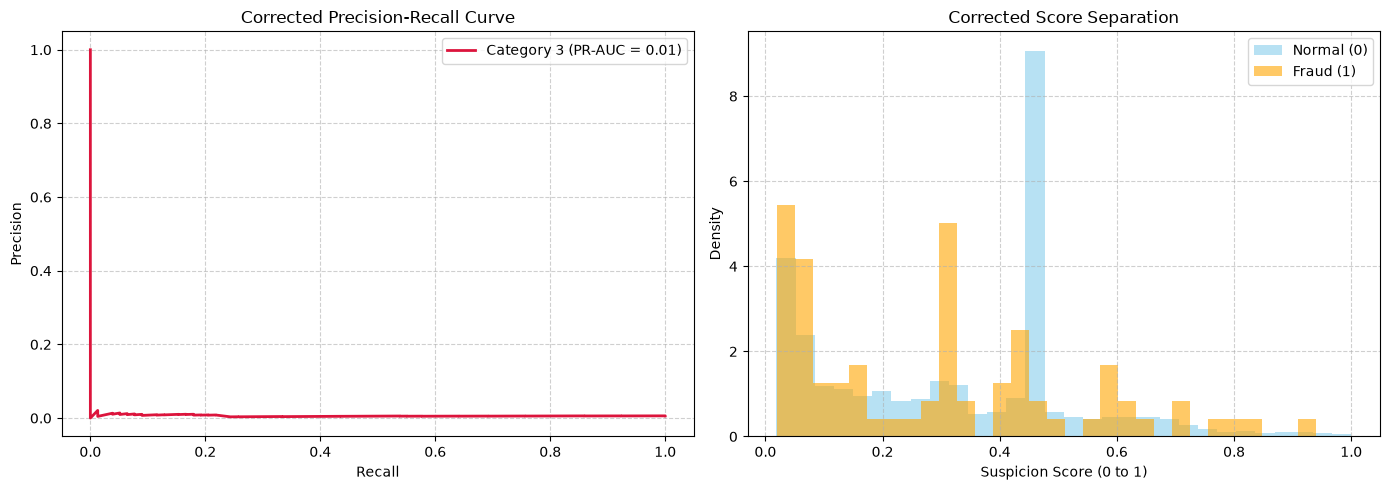

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score

# 1. LOAD ACTUAL GROUND TRUTH ANOMALIES (57 benchmark cases)
ANOM_PATH = r"C:\Users\Arpit Mishra\Desktop\AI-Bank-Transaction-and-Telecom-Analyzer\data\new_reduced\anomaly_ground_truth_reduced.csv"
anom_gt = pd.read_csv(ANOM_PATH)

# Extract ground-truth anomalous IDs
gt_txns = set(anom_gt["Transaction_ID"].dropna().astype(str).unique())
gt_cdrs = set(anom_gt["CDR_IDs"].dropna().astype(str).unique())

# Map Ground Truth to fused_df (Check both Transaction_ID and CDR_ID)
fused_df["target_is_anomaly"] = 0

if "Transaction_ID" in fused_df.columns:
    fused_df["target_is_anomaly"] = fused_df["Transaction_ID"].astype(str).isin(gt_txns).astype(int)

# Fallback/Additional check on CDR_ID if available
if "CDR_ID" in fused_df.columns:
    fused_df["target_is_anomaly"] = (
        fused_df["target_is_anomaly"] | fused_df["CDR_ID"].astype(str).isin(gt_cdrs)
    ).astype(int)

y_true = fused_df["target_is_anomaly"].values
y_scores_iso = fused_df["iso_score"].values
y_scores_ae = fused_df["ae_score"].values
y_scores_cat3 = fused_df["category_3_score"].values

total_anomalies = y_true.sum()
print(f"Total Transactions in Test Set: {len(fused_df)}")
print(f"Total True Ground-Truth Anomalies Matched: {total_anomalies} (out of 57)")

# =====================================================================
# 2. EVALUATE TOP-K PERFORMANCE (Corrected)
# =====================================================================
def evaluate_top_k(df, score_col, k_values=[10, 50, 100, 200]):
    sorted_df = df.sort_values(by=score_col, ascending=False).reset_index(drop=True)
    results = []
    for k in k_values:
        top_k = sorted_df.head(k)
        tp = top_k["target_is_anomaly"].sum()
        precision_at_k = tp / k
        recall_at_k = tp / total_anomalies if total_anomalies > 0 else 0.0
        results.append({
            "Top K": k,
            "True Positives Caught": tp,
            "Precision@K": f"{precision_at_k:.2%}",
            "Recall@K": f"{recall_at_k:.2%}"
        })
    return pd.DataFrame(results)

print("\n--- Isolation Forest Performance ---")
print(evaluate_top_k(fused_df, "iso_score"))

print("\n--- PyTorch Autoencoder Performance ---")
print(evaluate_top_k(fused_df, "ae_score"))

print("\n--- Category 3 Composite Model (Max-Pooling) Performance ---")
print(evaluate_top_k(fused_df, "category_3_score"))

# =====================================================================
# 3. GLOBAL AUC METRICS & PLOTS
# =====================================================================
if len(np.unique(y_true)) > 1:
    precision, recall, _ = precision_recall_curve(y_true, y_scores_cat3)
    pr_auc = auc(recall, precision)
    roc_auc = roc_auc_score(y_true, y_scores_cat3)
    
    print("\n--- Corrected Global Model Scores (Category 3 Composite) ---")
    print(f"PR-AUC Score: {pr_auc:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    # Plot Curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(recall, precision, label=f"Category 3 (PR-AUC = {pr_auc:.2f})", color="crimson", lw=2)
    axes[0].set_title("Corrected Precision-Recall Curve")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].legend()

    norm_scores = fused_df[fused_df["target_is_anomaly"] == 0]["category_3_score"]
    anom_scores = fused_df[fused_df["target_is_anomaly"] == 1]["category_3_score"]

    axes[1].hist(norm_scores, bins=30, alpha=0.6, label="Normal (0)", color="skyblue", density=True)
    axes[1].hist(anom_scores, bins=30, alpha=0.6, label="Fraud (1)", color="orange", density=True)
    axes[1].set_title("Corrected Score Separation")
    axes[1].set_xlabel("Suspicion Score (0 to 1)")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()